# Chapter 5 Exercises
## Exercise 5.1

Use the `print_sampled_tokens` function to print the sampling frequencies of the softmax probabilities scaled with the temperatures shown in figure. How often is the word pizza sampled in each case? Can you think of a faster and more accurate way to determine how often the word pizza is sampled?

In [1]:
import torch
import matplotlib.pyplot as plt
from gpt_2.pretrain import softmax_with_temperature

vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v:k for k,v in vocab.items()}

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
probas = torch.softmax(next_token_logits, dim=0)

def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample = [torch.multinomial(probas, num_samples=1).item()
            for i in range(1_000)]
  sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
  for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")

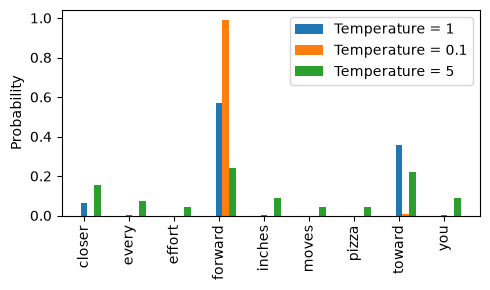

In [2]:

temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
  rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f"Temperature = {T}")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
print("Number of samplings (with print_sampled_tokens, 1000 trials)\n")
for T, probas in zip(temperatures, scaled_probas):
    print(f"Output probabilities ({T=})")
    print_sampled_tokens(probas)
    print('\n')


Number of samplings (with print_sampled_tokens, 1000 trials)

Output probabilities (T=1)
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


Output probabilities (T=0.1)
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


Output probabilities (T=5)
165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you




In [4]:
print("Number of expected samplings (fast way, 1000 trials\n")
torch.manual_seed(123)

for T, probas in zip(temperatures, scaled_probas):
    print(f"Output probabilities ({T=})")
    for i, proba in enumerate(probas):
        print(f"{int(proba * 1000)} x {inverse_vocab[i]}")
    print('\n')

Number of expected samplings (fast way, 1000 trials

Output probabilities (T=1)
60 x closer
1 x every
0 x effort
572 x forward
3 x inches
0 x moves
0 x pizza
357 x toward
4 x you


Output probabilities (T=0.1)
0 x closer
0 x every
0 x effort
990 x forward
0 x inches
0 x moves
0 x pizza
9 x toward
0 x you


Output probabilities (T=5)
154 x closer
74 x every
42 x effort
242 x forward
86 x inches
45 x moves
42 x pizza
220 x toward
89 x you




## Exercise 5.2

Play around with different temperatures and top-k settings. Based on your observations, can you think of applications where lower temperature and top-k settings are desired? Likewise, can you think of applications where higher temperature and top-k settings are preferred?

In [5]:
from tiktoken import get_encoding
from gpt_2.model import GPTModel, GPT_CONFIG_124M
from gpt_2.pretrain import load_weights_into_gpt
from gpt_2.gpt_download import download_and_load_gpt2
from gpt_2.pretrain import generate, token_ids_to_text, text_to_token_ids

NEW_CONFIG = GPT_CONFIG_124M.copy()

settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

NEW_CONFIG.update(settings)
NEW_CONFIG['qkv_bias'] = True

gpt = GPTModel(NEW_CONFIG)
tokenizer = get_encoding('gpt2')

load_weights_into_gpt(gpt, params)
gpt.eval()

I0000 00:00:1785770703.764450   10496 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785770703.837835   10496 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785770704.999773   10496 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [6]:
# Lower temperatures and top_k: 
# more deterministic output, ideal for structured outputs
# and formatted text (JSON, XML etc.)
torch.manual_seed(123)
temperature = 0.4
top_k = int(0.4 * GPT_CONFIG_124M['vocab_size'])

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids('What goes around', tokenizer),
    context_size=NEW_CONFIG['context_length'],
    max_new_tokens=50,
    temperature=temperature,
    top_k=top_k,
)

print('Output text: (low temperature and top_k)', token_ids_to_text(token_ids, tokenizer))

# Higher temperatures and top_k:
# more creative, various text, ideal for brainstorming,
# novel stories and creative work

temperature = 1.3
top_k = int(0.7 * GPT_CONFIG_124M['vocab_size'])

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids('What goes around', tokenizer),
    context_size=NEW_CONFIG['context_length'],
    max_new_tokens=50,
    temperature=temperature,
    top_k=top_k,
)

print('Output text(high temperature, high top_k): ', token_ids_to_text(token_ids, tokenizer))

Output text: (low temperature and top_k) What goes around comes around."

The next day, he was told by his family that he would be arrested.

"I got a call from my mother telling me that I had been arrested and that I would be arrested for a crime that I did
Output text(high temperature, high top_k):  What goes around negatives disturbs SF100rance already alienating RP320 of ship December 11, 2004 Click for BWStock.blogspotScanFixSHARE edits from achieve alumniet Bluzy Professional Orthodox Prayer page Films ear Tortynamic Blloe sac Dec stud demon Claith


## Exercise 5.3

What are the different combinations of settings for the generate function to force deterministic behavior, that is, disabling the random sampling such that it always produces the same outputs similar to the generate_simple function?

In [7]:
torch.manual_seed(123)

# we can use temperature equal to 0, with top_k=None
temperature = 0.0
top_k = None

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids('What goes around', tokenizer),
    context_size=NEW_CONFIG['context_length'],
    max_new_tokens=50,
    temperature=temperature,
    top_k=top_k,
)

print('Output text(zero temperature): ', token_ids_to_text(token_ids, tokenizer))

# Or top_k = 1
torch.manual_seed(123)
temperature = 1.2
top_k = 1

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids('What goes around', tokenizer),
    context_size=NEW_CONFIG['context_length'],
    max_new_tokens=50,
    temperature=temperature,
    top_k=top_k,
)

print('Output text(top_k = 1): ', token_ids_to_text(token_ids, tokenizer))

Output text(zero temperature):  What goes around comes around.

"I'm not sure if it's a good idea to have a lot of people in the room, but I think it's a good idea to have a lot of people in the room. I think it's a good
Output text(top_k = 1):  What goes around comes around.

"I'm not sure if it's a good idea to have a lot of people in the room, but I think it's a good idea to have a lot of people in the room. I think it's a good


## Exercise 5.4

After saving the weights, load the model and optimizer in a new Python session or Jupyter notebook file and continue pretraining it for one more epoch using the `train_model_simple` function.

In [2]:
import torch
import tiktoken
from gpt_2.model import GPTModel, GPT_CONFIG_124M
from gpt_2.dataset import get_root, create_data_loader_v1
from gpt_2.pretrain import train_model_simple

device = torch.device('cpu')

data_folder = get_root().parent.parent / 'data'
file_path = data_folder / 'model_and_optimizer.pth'
checkpoint = torch.load(file_path, map_location=device)

with open(data_folder / 'the-verdict.txt', 'r', encoding='utf-8') as fp:
    text_data = fp.read()

new_config = GPT_CONFIG_124M.copy()
new_config.update({'context_length': 256})
model = GPTModel(new_config)
tokenizer = tiktoken.get_encoding('gpt2')

model.load_state_dict(checkpoint['model_state_dict'])
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
model.to(device)
model.train()

train_ratio = 0.90
split_idx = int(len(text_data) * train_ratio)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_data_loader_v1(
    train_data,
    batch_size=2,
    max_length=new_config['context_length'],
    stride=new_config['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_data_loader_v1(
    val_data,
    batch_size=2,
    max_length=new_config['context_length'],
    stride=new_config['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=1, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 0.271 Val loss 6.545
Ep 1 (Step 000005): Train loss 0.244 Val loss 6.614
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


## Exercise 5.5

Calculate the training and validation set losses of the GPTModel with the pretrained weights from OpenAI on the “The Verdict” dataset.

In [6]:
import torch
from tiktoken import get_encoding
from gpt_2.dataset import get_root, create_data_loader_v1
from gpt_2.model import GPTModel, GPT_CONFIG_124M
from gpt_2.pretrain import load_weights_into_gpt, calc_loss_loader
from gpt_2.gpt_download import download_and_load_gpt2

torch.manual_seed(123)
device = torch.device('cpu')

data_folder = get_root().parent.parent / 'data'
with open(data_folder / 'the-verdict.txt', 'r', encoding='utf-8') as fp:
    text_data = fp.read()

train_ratio = 0.70
split_idx = int(len(text_data) * train_ratio)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(settings)
NEW_CONFIG['qkv_bias'] = True

train_loader = create_data_loader_v1(
    train_data,
    batch_size=2,
    max_length=NEW_CONFIG['context_length'],
    stride=NEW_CONFIG['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_data_loader_v1(
    val_data,
    batch_size=2,
    max_length=NEW_CONFIG['context_length'],
    stride=NEW_CONFIG['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

gpt = GPTModel(NEW_CONFIG)
tokenizer = get_encoding('gpt2')

load_weights_into_gpt(gpt, params)
gpt.to(device)
gpt.eval()

train_loss = calc_loss_loader(train_loader, gpt, device)
val_loss = calc_loss_loader(val_loader, gpt, device)

print(f"Train Loss: {train_loss:.3f}")
print(f"Validation Loss: {val_loss:.3f}")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
Train Loss: 3.622
Validation Loss: 3.681


## Exercise 5.6

Experiment with GPT-2 models of different sizes—for example, the largest 1,558 million parameter model—and compare the generated text to the 124 million model.

In [ ]:
import torch
from tiktoken import get_encoding
from gpt_2.dataset import get_root, create_data_loader_v1
from gpt_2.model import GPTModel, GPT_CONFIG_124M
from gpt_2.pretrain import load_weights_into_gpt, calc_loss_loader
from gpt_2.gpt_download import download_and_load_gpt2

torch.manual_seed(123)
device = torch.device('cpu')

data_folder = get_root().parent.parent / 'data'
with open(data_folder / 'the-verdict.txt', 'r', encoding='utf-8') as fp:
    text_data = fp.read()

train_ratio = 0.70
split_idx = int(len(text_data) * train_ratio)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

model_configs = {
  "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
  "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
  "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
  "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

model_name = "gpt2-xl (1558M)"

settings, params = download_and_load_gpt2(
    model_size="1558M", models_dir="gpt2"
)

NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG['qkv_bias'] = True

train_loader = create_data_loader_v1(
    train_data,
    batch_size=2,
    max_length=NEW_CONFIG['context_length'],
    stride=NEW_CONFIG['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_data_loader_v1(
    val_data,
    batch_size=2,
    max_length=NEW_CONFIG['context_length'],
    stride=NEW_CONFIG['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

gpt = GPTModel(NEW_CONFIG)
tokenizer = get_encoding('gpt2')

load_weights_into_gpt(gpt, params)
gpt.to(device)
gpt.eval()

train_loss = calc_loss_loader(train_loader, gpt, device)
val_loss = calc_loss_loader(val_loader, gpt, device)

print(f"Train Loss: {train_loss:.3f}")
print(f"Validation Loss: {val_loss:.3f}")

I0000 00:00:1785831682.892674    3366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785831684.307243    3366 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785831691.413785    3366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


File already exists and is up-to-date: gpt2/1558M/checkpoint
File already exists and is up-to-date: gpt2/1558M/encoder.json
File already exists and is up-to-date: gpt2/1558M/hparams.json
File already exists and is up-to-date: gpt2/1558M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/1558M/model.ckpt.index
File already exists and is up-to-date: gpt2/1558M/model.ckpt.meta
File already exists and is up-to-date: gpt2/1558M/vocab.bpe
